In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Loading the DS

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Teacher Model

In [3]:
def create_teacher():
    return keras.Sequential([
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(10)
    ])

Student Model

In [4]:
def create_student():
    return keras.Sequential([
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10)
    ])

Training the Teacher

In [5]:
teacher = create_teacher()

teacher.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

teacher.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9436 - loss: 0.1855 - val_accuracy: 0.9709 - val_loss: 0.0897
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9752 - loss: 0.0811 - val_accuracy: 0.9745 - val_loss: 0.0865
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.0550 - val_accuracy: 0.9794 - val_loss: 0.0709
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9867 - loss: 0.0419 - val_accuracy: 0.9766 - val_loss: 0.0841
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9895 - loss: 0.0324 - val_accuracy: 0.9777 - val_loss: 0.0812


Baseline Student

In [13]:
student_baseline = create_student()

student_baseline.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

student_baseline.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9275 - loss: 0.2550 - val_accuracy: 0.9618 - val_loss: 0.1354
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9670 - loss: 0.1108 - val_accuracy: 0.9723 - val_loss: 0.0947
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9771 - loss: 0.0764 - val_accuracy: 0.9713 - val_loss: 0.0908
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0581 - val_accuracy: 0.9766 - val_loss: 0.0735
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9866 - loss: 0.0443 - val_accuracy: 0.9755 - val_loss: 0.0771


Distillation

In [7]:
T = 5.0
alpha = 0.7

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
kl_div = keras.losses.KLDivergence()

optimizer = keras.optimizers.Adam()

In [8]:
student = create_student()

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(64)

for epoch in range(5):
    for x_batch, y_batch in train_dataset:

        with tf.GradientTape() as tape:
            teacher_logits = teacher(x_batch, training=False)
            student_logits = student(x_batch, training=True)

            # Soft targets
            teacher_probs = tf.nn.softmax(teacher_logits / T)
            student_probs = tf.nn.softmax(student_logits / T)

            soft_loss = kl_div(teacher_probs, student_probs) * (T * T)

            hard_loss = loss_fn(y_batch, student_logits)

            loss = alpha * soft_loss + (1 - alpha) * hard_loss

        grads = tape.gradient(loss, student.trainable_variables)
        optimizer.apply_gradients(zip(grads, student.trainable_variables))

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [10]:
student.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

Evaluation & Plotting

In [16]:
teacher_loss, teacher_acc = teacher.evaluate(x_test, y_test, verbose=0)

baseline_loss, baseline_acc = student_baseline.evaluate(x_test, y_test, verbose=0)

distilled_loss, distilled_acc = student.evaluate(x_test, y_test, verbose=0)

In [17]:
models = ["Teacher", "Student (Baseline)", "Student (Distilled)"]

accuracies = [teacher_acc, baseline_acc, distilled_acc]
losses = [teacher_loss, baseline_loss, distilled_loss]

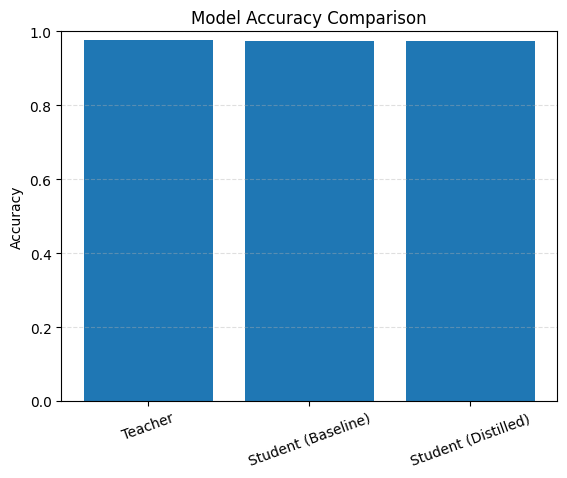

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

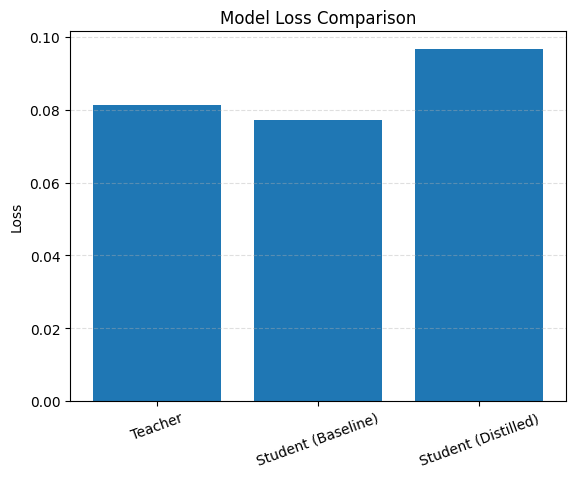

In [19]:
plt.figure()
plt.bar(models, losses)
plt.title("Model Loss Comparison")
plt.ylabel("Loss")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()